In [ ]:
# Cell 1: Install required packages
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install torch-geometric
!pip install opencv-python
!pip install kaggle
!pip install einops
!pip install openai networkx matplotlib scikit-learn

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.9 MB/s eta 0:00:00


In [ ]:
!pip uninstall -y openai
!pip install openai==0.28.1

Found existing installation: openai 2.12.0
Uninstalling openai-2.12.0:
  Successfully uninstalled openai-2.12.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.7 MB/s eta 0:00:00


In [ ]:
# Cell 2: Upload Kaggle credentials
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"hasnatnoorhassan","key":"477a91f49f64dc6bbb410f6fe0327f71"}'}

In [ ]:
# Cell 3: Setup Kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Cell 4: Download datasets
# RLVS dataset
!kaggle datasets download -d musreaghaseb/skeleton-based-rlvs-dataset -p /content/rlvs
!unzip /content/rlvs/skeleton-based-rlvs-dataset.zip -d /content/rlvs/data

# # NTU-V dataset (optional, for more data)
# !kaggle datasets download -d musreaghaseb/ntu-violence-dataset -p /content/ntuv
# !unzip /content/ntuv/ntu-violence-dataset.zip -d /content/ntuv/data

Dataset URL: https://www.kaggle.com/datasets/musreaghaseb/skeleton-based-rlvs-dataset
License(s): apache-2.0
 84% 60.0M/71.0M [00:00<00:00, 627MB/s]
100% 71.0M/71.0M [00:00<00:00, 633MB/s]
Archive:  /content/rlvs/skeleton-based-rlvs-dataset.zip
  inflating: /content/rlvs/data/Numy Version of Skeleton RLVS/ProcessedData/train_data.npy  
  inflating: /content/rlvs/data/Numy Version of Skeleton RLVS/ProcessedData/train_label.pkl  
  inflating: /content/rlvs/data/Numy Version of Skeleton RLVS/ProcessedData/val_data.npy  
  inflating: /content/rlvs/data/Numy Version of Skeleton RLVS/ProcessedData/val_label.pkl  
  inflating: /content/rlvs/data/Skeleton Keypoint (RLVS) Dataset/FormattedData/NonViolence/NV_602.avi.json  
  inflating: /content/rlvs/data/Skeleton Keypoint (RLVS) Dataset/FormattedData/NonViolence/NV_863.avi.json  
  inflating: /content/rlvs/data/Skeleton Keypoint (RLVS) Dataset/FormattedData/NonViolence/NV_864.avi.json  
  inflating: /content/rlvs/data/Skeleton Keypoint (RLVS) D

In [ ]:
# Cell 5: Import all libraries
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch_geometric.nn import GCNConv, GATConv
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import openai
import json
import networkx as nx
from typing import Dict, List, Tuple
import os

In [ ]:
# Cell 6: Load RLVS Dataset
rlvs_base = '/content/rlvs/data/Numy Version of Skeleton RLVS/ProcessedData/'

# Load training data
X_train = np.load(rlvs_base + 'train_data.npy')
with open(rlvs_base + 'train_label.pkl', 'rb') as f:
    y_train = np.array(pickle.load(f)[1])

# Load validation data
X_val = np.load(rlvs_base + 'val_data.npy')
with open(rlvs_base + 'val_label.pkl', 'rb') as f:
    y_val = np.array(pickle.load(f)[1])

# Split validation into val and test
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.5, random_state=42)

print("RLVS Dataset Loaded:")
print(f"Train: {X_train.shape}, Labels: {y_train.shape}")
print(f"Val: {X_val.shape}, Labels: {y_val.shape}")
print(f"Test: {X_test.shape}, Labels: {y_test.shape}")
print(f"Unique labels: {np.unique(y_train)}")

RLVS Dataset Loaded:
Train: (1561, 3, 300, 25, 2), Labels: (1561,)
Val: (195, 3, 300, 25, 2), Labels: (195,)
Test: (195, 3, 300, 25, 2), Labels: (195,)
Unique labels: [0 1]


In [ ]:
# Cell 7: Create PyTorch Dataset
class SkeletonDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create data loaders
train_dataset = SkeletonDataset(X_train, y_train)
val_dataset = SkeletonDataset(X_val, y_val)
test_dataset = SkeletonDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("Data loaders created successfully!")

Data loaders created successfully!


In [ ]:
# Cell 8: Set up OpenAI API
# IMPORTANT: Replace with your actual OpenAI API key
openai.api_key = "*****"

def query_openai(prompt: str, model: str = "gpt-4") -> str:
    """Query OpenAI API for knowledge extraction."""
    try:
        response = openai.ChatCompletion.create(
            model=model,
            messages=[
                {"role": "system", "content": "You are an expert in human action recognition and violence detection from skeletal data. You understand biomechanics, human movement patterns, and violent behavior indicators."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.7,
            max_tokens=2000
        )
        return response.choices[0].message.content
    except Exception as e:
        print(f"Error querying OpenAI: {e}")
        return ""

print("OpenAI API configured!")

OpenAI API configured!


In [ ]:
# Cell 9: Generate Violence Detection Knowledge Graph
def generate_violence_knowledge():
    """Generate violence detection knowledge using OpenAI."""

    prompt = """
    Generate a comprehensive knowledge graph for skeleton-based violence detection using 25 body joints (NTU skeleton format).

    The 25 joints are indexed 0-24:
    0: base of spine, 1: middle spine, 2: neck, 3: head
    4: left shoulder, 5: left elbow, 6: left wrist, 7: left hand
    8: right shoulder, 9: right elbow, 10: right wrist, 11: right hand
    12: left hip, 13: left knee, 14: left ankle, 15: left foot
    16: right hip, 17: right knee, 18: right ankle, 19: right foot
    20: spine, 21: left hand tip, 22: left thumb, 23: right hand tip, 24: right thumb

    Analyze violent actions (punching, kicking, hitting, pushing, striking) and provide:

    1. **critical_joints**: List 10-15 most important joint indices for violence detection
    2. **joint_relationships**: List of [joint1_idx, joint2_idx, "relationship_type", importance_score_0_to_1]
       - Focus on limb extensions, aggressive postures, impact trajectories
       - At least 15 relationships
    3. **temporal_patterns**: List of {
         "pattern_name": descriptive name,
         "description": what this pattern indicates,
         "typical_duration_frames": approximate frame count,
         "critical_joints": joint indices involved
       }
       - At least 5 patterns
    4. **spatial_features**: List of {
         "feature_name": name,
         "description": what this indicates about violence,
         "involved_joints": list of joint indices,
         "characteristic": key characteristic to detect
       }
       - At least 5 features

    Return ONLY a valid JSON object with these four keys. Be specific with joint indices and scores.
    """

    print("Querying OpenAI for violence detection knowledge...")
    response = query_openai(prompt)

    try:
        # Try to parse JSON from response
        # Sometimes GPT wraps JSON in markdown, so clean it
        response = response.strip()
        if response.startswith("```json"):
            response = response[7:]
        if response.startswith("```"):
            response = response[3:]
        if response.endswith("```"):
            response = response[:-3]

        knowledge = json.loads(response.strip())
        print("✓ Successfully generated knowledge from OpenAI")
        return knowledge
    except Exception as e:
        print(f"⚠ Failed to parse OpenAI response: {e}")
        print("Using fallback knowledge graph...")
        return get_fallback_knowledge()

def get_fallback_knowledge():
    """Fallback knowledge graph if OpenAI fails."""
    print("Using fallback knowledge graph...")
    return {
        "critical_joints": [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24],
        "joint_relationships": [
            [4, 5, "left_arm_extension", 0.9],
            [5, 6, "left_forearm_action", 0.85],
            [6, 7, "left_hand_strike", 0.95],
            [8, 9, "right_arm_extension", 0.9],
            [9, 10, "right_forearm_action", 0.85],
            [10, 11, "right_hand_strike", 0.95],
            [12, 13, "left_leg_movement", 0.8],
            [13, 14, "left_knee_kick", 0.85],
            [14, 15, "left_foot_impact", 0.9],
            [16, 17, "right_leg_movement", 0.8],
            [17, 18, "right_knee_kick", 0.85],
            [18, 19, "right_foot_impact", 0.9],
            [20, 4, "torso_left_arm", 0.75],
            [20, 8, "torso_right_arm", 0.75],
            [0, 3, "spine_head_alignment", 0.7]
        ],
        "temporal_patterns": [
            {
                "pattern_name": "rapid_limb_extension",
                "description": "Fast acceleration of arms or legs indicating striking motion",
                "typical_duration_frames": 8,
                "critical_joints": [4, 5, 6, 7, 8, 9, 10, 11]
            },
            {
                "pattern_name": "impact_deceleration",
                "description": "Sudden stop of limb motion indicating contact/impact",
                "typical_duration_frames": 5,
                "critical_joints": [7, 11, 15, 19]
            },
            {
                "pattern_name": "aggressive_stance",
                "description": "Forward-leaning posture with raised limbs",
                "typical_duration_frames": 15,
                "critical_joints": [0, 1, 2, 20, 4, 8]
            },
            {
                "pattern_name": "kicking_motion",
                "description": "Single leg support with other leg raised and extended",
                "typical_duration_frames": 10,
                "critical_joints": [12, 13, 14, 15, 16, 17, 18, 19]
            },
            {
                "pattern_name": "defensive_recoil",
                "description": "Backward motion of upper body after impact",
                "typical_duration_frames": 12,
                "critical_joints": [0, 1, 2, 3, 20]
            }
        ],
        "spatial_features": [
            {
                "feature_name": "extended_arms",
                "description": "Arms extended away from body center, typical of punching",
                "involved_joints": [4, 5, 6, 7, 8, 9, 10, 11],
                "characteristic": "high_distance_from_torso"
            },
            {
                "feature_name": "raised_leg",
                "description": "Single leg raised significantly above ground level",
                "involved_joints": [13, 14, 15, 17, 18, 19],
                "characteristic": "vertical_displacement"
            },
            {
                "feature_name": "forward_lean",
                "description": "Spine and head tilted forward, aggressive posture",
                "involved_joints": [0, 1, 2, 3, 20],
                "characteristic": "forward_angle"
            },
            {
                "feature_name": "wide_stance",
                "description": "Legs spread apart for stability during violence",
                "involved_joints": [12, 13, 14, 15, 16, 17, 18, 19],
                "characteristic": "horizontal_distance"
            },
            {
                "feature_name": "hand_trajectory",
                "description": "Direct linear path of hands toward target",
                "involved_joints": [7, 11, 21, 22, 23, 24],
                "characteristic": "linear_velocity"
            }
        ]
    }

# Generate or load knowledge
violence_knowledge = generate_violence_knowledge()

print("\n" + "="*60)
print("GENERATED KNOWLEDGE GRAPH")
print("="*60)
print(json.dumps(violence_knowledge, indent=2))
print("="*60)

Querying OpenAI for violence detection knowledge...
✓ Successfully generated knowledge from OpenAI

GENERATED KNOWLEDGE GRAPH
{
  "critical_joints": [
    2,
    3,
    4,
    5,
    6,
    8,
    9,
    10,
    12,
    13,
    16,
    17
  ],
  "joint_relationships": [
    [
      4,
      5,
      "extension",
      0.9
    ],
    [
      5,
      6,
      "extension",
      0.9
    ],
    [
      8,
      9,
      "extension",
      0.9
    ],
    [
      9,
      10,
      "extension",
      0.9
    ],
    [
      2,
      3,
      "alignment",
      0.7
    ],
    [
      12,
      13,
      "extension",
      0.8
    ],
    [
      16,
      17,
      "extension",
      0.8
    ],
    [
      4,
      6,
      "impact_trajectory",
      0.9
    ],
    [
      8,
      10,
      "impact_trajectory",
      0.9
    ],
    [
      2,
      4,
      "aggressive_posture",
      0.7
    ],
    [
      2,
      8,
      "aggressive_posture",
      0.7
    ],
    [
      4,
      5,
     

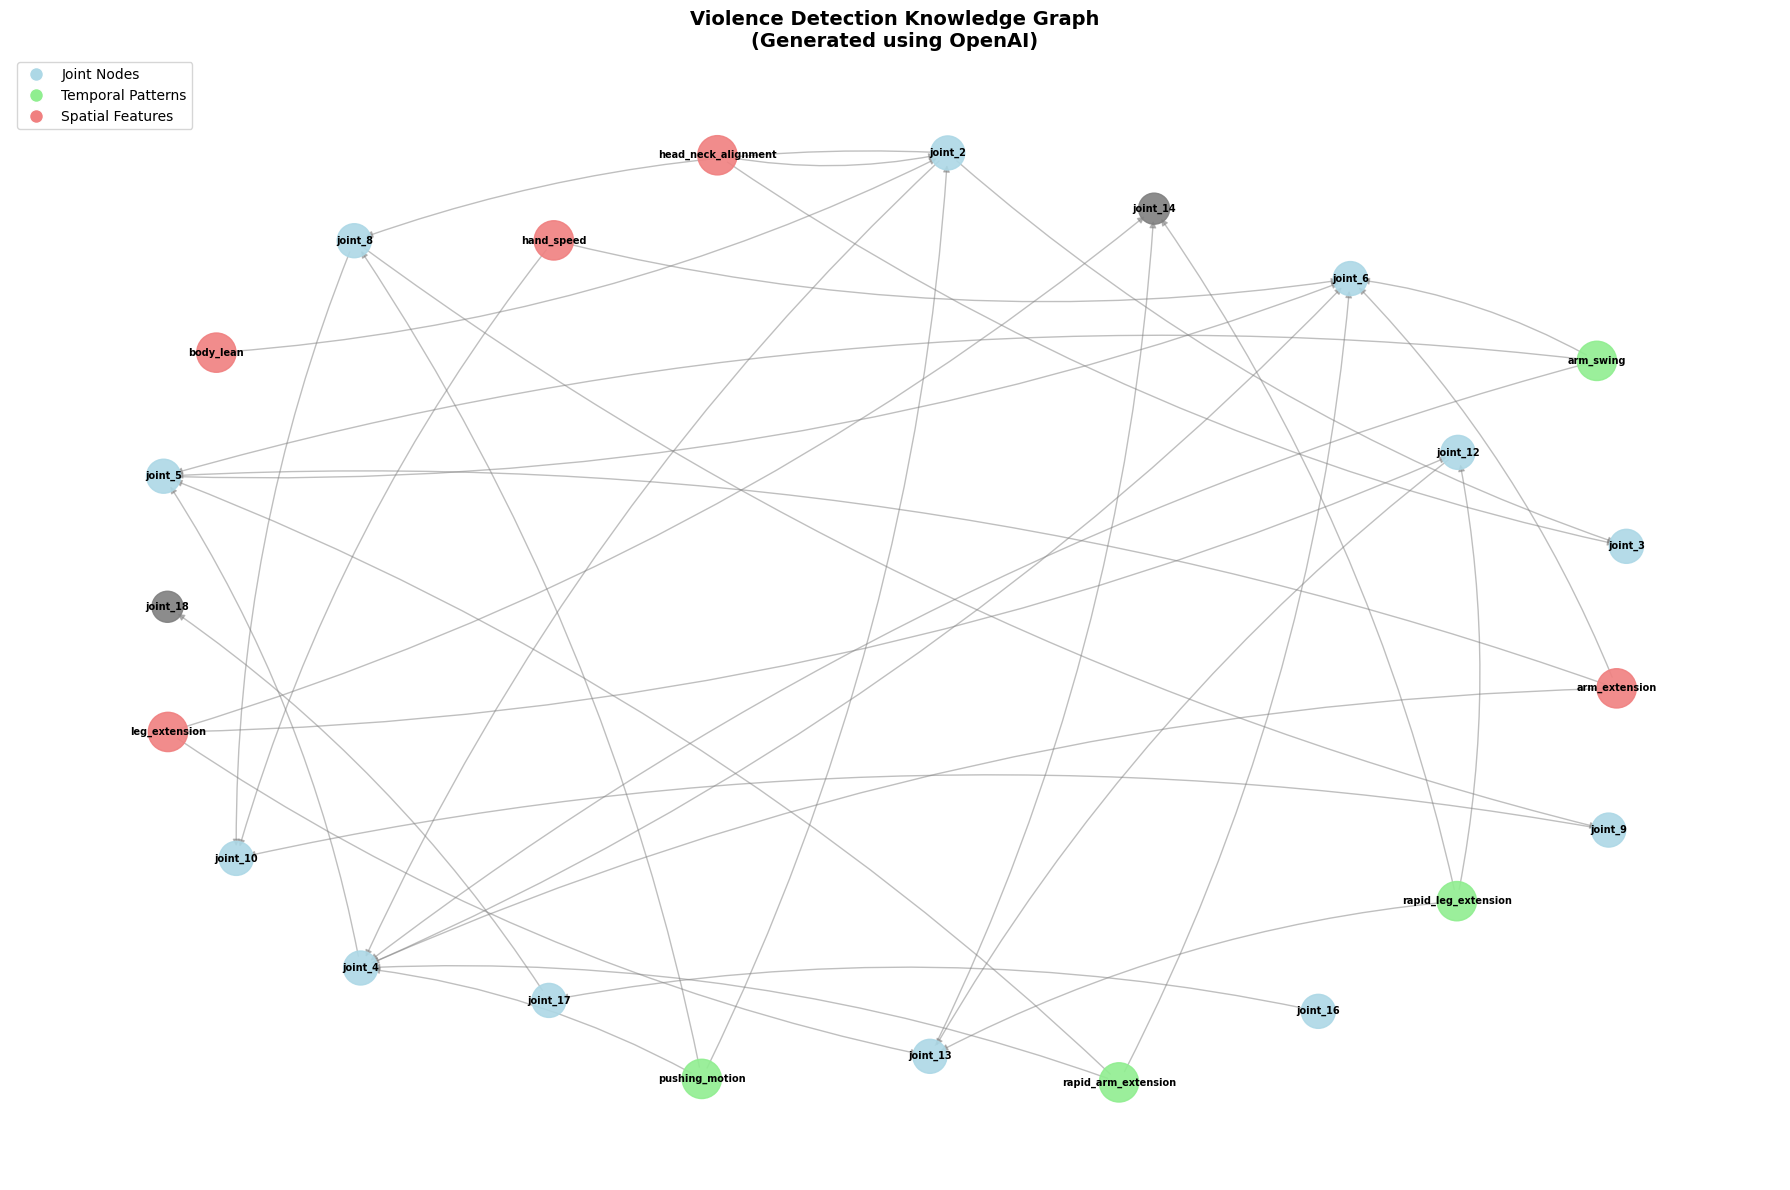


Knowledge Graph Statistics:
  Total Nodes: 23
  - Joint Nodes: 12
  - Pattern Nodes: 4
  - Spatial Feature Nodes: 5
  Total Edges: 36
  Average Node Degree: 3.13
  KG Adjacency Matrix Shape: (25, 25)
  Non-zero edges in adjacency: 26


In [ ]:
# Cell 10: Create Knowledge Graph Structure
class KnowledgeGraph:
    def __init__(self, knowledge_dict):
        self.G = nx.DiGraph()
        self.knowledge = knowledge_dict
        self.build_graph()

    def build_graph(self):
        """Build NetworkX graph from knowledge."""
        # Add critical joints as nodes
        for joint_idx in self.knowledge.get('critical_joints', []):
            self.G.add_node(f"joint_{joint_idx}",
                          node_type='joint',
                          importance=1.0,
                          joint_id=joint_idx)

        # Add relationships as edges
        for rel in self.knowledge.get('joint_relationships', []):
            j1, j2, rel_type, score = rel
            self.G.add_edge(f"joint_{j1}", f"joint_{j2}",
                          relation=rel_type,
                          weight=score)

        # Add pattern nodes
        for pattern in self.knowledge.get('temporal_patterns', []):
            pattern_name = pattern['pattern_name']
            self.G.add_node(pattern_name,
                          node_type='pattern',
                          description=pattern['description'],
                          duration=pattern.get('typical_duration_frames', 10))

            # Connect to critical joints
            for joint_idx in pattern.get('critical_joints', []):
                if f"joint_{joint_idx}" in self.G:
                    self.G.add_edge(pattern_name, f"joint_{joint_idx}",
                                  relation='uses', weight=0.8)

        # Add spatial feature nodes
        for feature in self.knowledge.get('spatial_features', []):
            feature_name = feature['feature_name']
            self.G.add_node(feature_name,
                          node_type='spatial_feature',
                          description=feature['description'],
                          characteristic=feature.get('characteristic', ''))

            # Connect to involved joints
            for joint_idx in feature.get('involved_joints', []):
                if f"joint_{joint_idx}" in self.G:
                    self.G.add_edge(feature_name, f"joint_{joint_idx}",
                                  relation='involves', weight=0.75)

    def visualize(self, save_path='knowledge_graph.png'):
        """Visualize the knowledge graph."""
        plt.figure(figsize=(18, 12))

        # Color nodes by type
        color_map = []
        node_sizes = []
        for node in self.G:
            node_type = self.G.nodes[node].get('node_type', 'unknown')
            if node_type == 'joint':
                color_map.append('lightblue')
                node_sizes.append(600)
            elif node_type == 'pattern':
                color_map.append('lightgreen')
                node_sizes.append(800)
            elif node_type == 'spatial_feature':
                color_map.append('lightcoral')
                node_sizes.append(800)
            else:
                color_map.append('gray')
                node_sizes.append(500)

        # Layout
        pos = nx.spring_layout(self.G, k=3, iterations=50, seed=42)

        # Draw
        nx.draw_networkx_nodes(self.G, pos, node_color=color_map,
                               node_size=node_sizes, alpha=0.9)
        nx.draw_networkx_labels(self.G, pos, font_size=7, font_weight='bold')
        nx.draw_networkx_edges(self.G, pos, edge_color='gray',
                               arrows=True, arrowsize=10, alpha=0.5,
                               connectionstyle='arc3,rad=0.1')

        # Legend
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='lightblue',
                   markersize=10, label='Joint Nodes'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgreen',
                   markersize=10, label='Temporal Patterns'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='lightcoral',
                   markersize=10, label='Spatial Features')
        ]
        plt.legend(handles=legend_elements, loc='upper left')

        plt.title("Violence Detection Knowledge Graph\n(Generated using OpenAI)",
                  fontsize=14, fontweight='bold')
        plt.axis('off')
        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.show()

    def get_adjacency_matrix(self, num_joints=25):
        """Get adjacency matrix for GNN."""
        adj_matrix = np.zeros((num_joints, num_joints))

        for edge in self.G.edges():
            # Only consider edges between joints
            if edge[0].startswith('joint_') and edge[1].startswith('joint_'):
                i = int(edge[0].split('_')[1])
                j = int(edge[1].split('_')[1])
                weight = self.G[edge[0]][edge[1]].get('weight', 1.0)
                adj_matrix[i, j] = weight
                adj_matrix[j, i] = weight  # Symmetric

        return adj_matrix

    def get_statistics(self):
        """Get knowledge graph statistics."""
        stats = {
            'total_nodes': self.G.number_of_nodes(),
            'total_edges': self.G.number_of_edges(),
            'joint_nodes': len([n for n in self.G.nodes() if self.G.nodes[n].get('node_type') == 'joint']),
            'pattern_nodes': len([n for n in self.G.nodes() if self.G.nodes[n].get('node_type') == 'pattern']),
            'spatial_nodes': len([n for n in self.G.nodes() if self.G.nodes[n].get('node_type') == 'spatial_feature']),
            'avg_degree': sum(dict(self.G.degree()).values()) / self.G.number_of_nodes() if self.G.number_of_nodes() > 0 else 0
        }
        return stats

# Create knowledge graph
kg = KnowledgeGraph(violence_knowledge)
kg.visualize()

# Get adjacency matrix
kg_adj_matrix = kg.get_adjacency_matrix()

# Print statistics
stats = kg.get_statistics()
print("\nKnowledge Graph Statistics:")
print(f"  Total Nodes: {stats['total_nodes']}")
print(f"  - Joint Nodes: {stats['joint_nodes']}")
print(f"  - Pattern Nodes: {stats['pattern_nodes']}")
print(f"  - Spatial Feature Nodes: {stats['spatial_nodes']}")
print(f"  Total Edges: {stats['total_edges']}")
print(f"  Average Node Degree: {stats['avg_degree']:.2f}")
print(f"  KG Adjacency Matrix Shape: {kg_adj_matrix.shape}")
print(f"  Non-zero edges in adjacency: {np.count_nonzero(kg_adj_matrix)}")

In [ ]:
# Cell 11: Helper function for batched edge indices
def get_batched_edge_index(edge_index_single, num_graphs, V):
    """Create batched edge indices for multiple graphs."""
    edge_list = []
    for i in range(num_graphs):
        offset_edges = edge_index_single + i * V
        edge_list.append(offset_edges)
    return torch.cat(edge_list, dim=1)

In [ ]:
# Cell 12: Knowledge-Enhanced GNN Module
class KnowledgeEnhancedGNN(nn.Module):
    """GNN module that processes both skeleton and knowledge graph structures."""

    def __init__(self, in_channels, hidden_channels, kg_adj_matrix):
        super().__init__()

        # Convert KG adjacency to edge index
        self.register_buffer('kg_edge_index',
                           self._adj_to_edge_index(kg_adj_matrix))
        self.register_buffer('kg_edge_weight',
                           self._get_edge_weights(kg_adj_matrix))

        # GNN layers with knowledge graph structure
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.bn1 = nn.BatchNorm1d(hidden_channels)
        self.bn2 = nn.BatchNorm1d(hidden_channels)

        # Attention mechanism to combine skeleton and knowledge features
        self.attention = nn.Sequential(
            nn.Linear(hidden_channels * 2, hidden_channels),
            nn.Tanh(),
            nn.Linear(hidden_channels, 1),
            nn.Sigmoid()
        )

        self.dropout = nn.Dropout(0.3)

    def _adj_to_edge_index(self, adj_matrix):
        """Convert adjacency matrix to edge index format."""
        edge_index = torch.nonzero(torch.tensor(adj_matrix), as_tuple=False).t()
        return edge_index.long()

    def _get_edge_weights(self, adj_matrix):
        """Extract edge weights from adjacency matrix."""
        edges = torch.nonzero(torch.tensor(adj_matrix), as_tuple=False)
        weights = torch.tensor([adj_matrix[e[0], e[1]] for e in edges],
                              dtype=torch.float32)
        return weights

    def forward(self, x, skeleton_edge_index):
        """
        Args:
            x: Node features [num_nodes, in_channels]
            skeleton_edge_index: Skeleton graph edges
        Returns:
            x_fused: Fused features
            attention_weights: Attention scores
        """
        # Process through skeleton structure
        x_skeleton = self.conv1(x, skeleton_edge_index)
        x_skeleton = self.bn1(x_skeleton)
        x_skeleton = F.relu(x_skeleton)
        x_skeleton = self.dropout(x_skeleton)
        x_skeleton = self.conv2(x_skeleton, skeleton_edge_index)
        x_skeleton = self.bn2(x_skeleton)

        # Process through knowledge graph structure
        if self.kg_edge_index.shape[1] > 0:  # Check if KG has edges
            x_knowledge = self.conv1(x, self.kg_edge_index)
            x_knowledge = self.bn1(x_knowledge)
            x_knowledge = F.relu(x_knowledge)
            x_knowledge = self.dropout(x_knowledge)
            x_knowledge = self.conv2(x_knowledge, self.kg_edge_index)
            x_knowledge = self.bn2(x_knowledge)

            # Attention-based fusion
            combined = torch.cat([x_skeleton, x_knowledge], dim=-1)
            attention_weights = self.attention(combined)

            x_fused = attention_weights * x_skeleton + (1 - attention_weights) * x_knowledge
        else:
            # If no KG edges, just use skeleton
            x_fused = x_skeleton
            attention_weights = torch.ones(x_skeleton.shape[0], 1).to(x.device)

        return x_fused, attention_weights

In [ ]:
# Cell 13: ST-GCN Block
class STGCNBlock(nn.Module):
    """Spatial-Temporal Graph Convolutional Block."""

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.gcn = GCNConv(in_channels, out_channels)
        self.tcn = nn.Conv2d(out_channels, out_channels,
                            kernel_size=(9, 1), stride=(stride, 1),
                            padding=(4, 0))
        self.bn = nn.BatchNorm2d(out_channels)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x, edge_index_single, V=25, M=2):
        N, C, T, V, M = x.shape
        num_graphs = N * T * M
        edge_index_batched = get_batched_edge_index(edge_index_single, num_graphs, V).to(x.device)

        # Reshape for GCN
        x = x.permute(0, 2, 4, 3, 1)  # (N, T, M, V, C)
        x = x.reshape(num_graphs * V, C)

        # GCN
        x = self.gcn(x, edge_index_batched)

        # Reshape back to 5D
        x = x.view(N, T, M, V, -1)
        x = x.permute(0, 4, 1, 3, 2)  # (N, out_C, T, V, M)

        # TCN (flatten V*M)
        x_tcn = x.reshape(N, -1, T, V * M)
        x_tcn = self.tcn(x_tcn)
        x_tcn = self.bn(x_tcn)
        x_tcn = self.dropout(x_tcn)

        # Back to 5D
        x = x_tcn.reshape(N, -1, T, V, M)
        return F.relu(x)

In [ ]:
# Cell 14: ST-GCN Only Model (Pipeline 1 Experiment)
class STGCNOnlyModel(nn.Module):
    """ST-GCN only model - Pipeline 1 experiment."""

    def __init__(self, num_classes=2, in_channels=3, num_joints=25, num_persons=2):
        super().__init__()
        self.num_joints = num_joints
        self.num_persons = num_persons

        # Skeleton edges (NTU skeleton structure)
        edges = [
            (0,1), (1,20), (20,2), (2,3),
            (20,4), (4,5), (5,6), (6,7), (7,21), (7,22),
            (20,8), (8,9), (9,10), (10,11), (11,23), (11,24),
            (0,12), (12,13), (13,14), (14,15),
            (0,16), (16,17), (17,18), (18,19),
        ]
        edges = edges + [(j, i) for i, j in edges]
        self.edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous().cuda()

        # Pipeline 1: ST-GCN only
        self.p1_block1 = STGCNBlock(in_channels, 64)
        self.p1_block2 = STGCNBlock(64, 128)

        # Fusion / classifier
        self.fusion = nn.Sequential(
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3)
        )

        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        N, C, T, V, M = x.shape

        # Pipeline 1: ST-GCN
        out = self.p1_block1(x, self.edge_index, V, M)
        out = self.p1_block2(out, self.edge_index, V, M)
        out = out.mean(dim=[2, 3, 4])  # (N, 128)

        # Fusion and classification
        out = self.fusion(out)
        out = self.fc(out)
        return out


In [ ]:
# Cell 15: Initialize ST-GCN Only Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = STGCNOnlyModel(
    num_classes=2,
    in_channels=3,
    num_joints=25,
    num_persons=2
).to(device)

print(f"\nModel initialized successfully!")
print(f"Architecture: ST-GCN Only (Pipeline 1)")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")


In [ ]:
# Cell 16: Training Setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

num_epochs = 50
best_val_acc = 0.0
best_model_state = None

# Track metrics
train_losses = []
val_losses = []
train_accs = []
val_accs = []

print("Training setup complete!")

Training setup complete!


In [ ]:
print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_idx, (data, labels) in enumerate(train_loader):
        data, labels = data.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()

        if (batch_idx + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] Batch [{batch_idx+1}/{len(train_loader)}] "
                  f"Loss: {loss.item():.4f}")

    train_loss /= len(train_loader)
    train_acc = 100.0 * train_correct / train_total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # Validation phase
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for data, labels in val_loader:
            data, labels = data.to(device), labels.to(device)
            outputs = model(data)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100.0 * val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Learning rate scheduling
    scheduler.step(val_loss)

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        print(f"✓ New best model saved! Val Acc: {val_acc:.2f}%")

    print(f"\nEpoch [{epoch+1}/{num_epochs}] Summary:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print("-" * 60)

print("\n" + "="*60)
print("TRAINING COMPLETE")
print("="*60)
print(f"Best Validation Accuracy: {best_val_acc:.2f}%")


STARTING TRAINING
Epoch [1/50] Batch [10/49] Loss: 0.5046
Epoch [1/50] Batch [20/49] Loss: 0.3444
Epoch [1/50] Batch [30/49] Loss: 0.4919
Epoch [1/50] Batch [40/49] Loss: 0.1857
✓ New best model saved! Val Acc: 77.44%

Epoch [1/50] Summary:
  Train Loss: 0.4014 | Train Acc: 81.49%
  Val Loss: 0.4317 | Val Acc: 77.44%
------------------------------------------------------------
Epoch [2/50] Batch [10/49] Loss: 0.4947
Epoch [2/50] Batch [20/49] Loss: 0.2900
Epoch [2/50] Batch [30/49] Loss: 0.2789
Epoch [2/50] Batch [40/49] Loss: 0.2876

Epoch [2/50] Summary:
  Train Loss: 0.3091 | Train Acc: 87.19%
  Val Loss: 0.8224 | Val Acc: 68.21%
------------------------------------------------------------
Epoch [3/50] Batch [10/49] Loss: 0.2224
Epoch [3/50] Batch [20/49] Loss: 0.3609
Epoch [3/50] Batch [30/49] Loss: 0.1921
Epoch [3/50] Batch [40/49] Loss: 0.1692
✓ New best model saved! Val Acc: 77.95%

Epoch [3/50] Summary:
  Train Loss: 0.2872 | Train Acc: 88.02%
  Val Loss: 0.6375 | Val Acc: 77.

In [ ]:
model.load_state_dict(best_model_state)
model.eval()

test_preds = []
test_labels = []
test_probs = []

with torch.no_grad():
    for data, labels in test_loader:
        data, labels = data.to(device), labels.to(device)
        outputs = model(data)
        probs = F.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)

        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())
        test_probs.extend(probs.cpu().numpy()[:, 1])

# Calculate metrics
test_acc = accuracy_score(test_labels, test_preds)
test_precision = precision_score(test_labels, test_preds, average='binary')
test_recall = recall_score(test_labels, test_preds, average='binary')
test_f1 = f1_score(test_labels, test_preds, average='binary')

print("\n" + "="*60)
print("TEST SET RESULTS")
print("="*60)
print(f"Accuracy:  {test_acc*100:.2f}%")
print(f"Precision: {test_precision*100:.2f}%")
print(f"Recall:    {test_recall*100:.2f}%")
print(f"F1-Score:  {test_f1*100:.2f}%")
print("="*60)


TEST SET RESULTS
Accuracy:  89.74%
Precision: 91.43%
Recall:    89.72%
F1-Score:  90.57%


In [ ]:
model.load_state_dict(best_model_state)
model.eval()

test_preds = []
test_labels = []
test_probs = []

with torch.no_grad():
    for data, labels in test_loader:
        data, labels = data.to(device), labels.to(device)
        outputs = model(data)
        probs = F.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)

        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())
        test_probs.extend(probs.cpu().numpy()[:, 1])

# Calculate metrics
test_acc = accuracy_score(test_labels, test_preds)
test_precision = precision_score(test_labels, test_preds, average='binary')
test_recall = recall_score(test_labels, test_preds, average='binary')
test_f1 = f1_score(test_labels, test_preds, average='binary')

print("\n" + "="*60)
print("TEST SET RESULTS")
print("="*60)
print(f"Accuracy:  {test_acc*100:.2f}%")
print(f"Precision: {test_precision*100:.2f}%")
print(f"Recall:    {test_recall*100:.2f}%")
print(f"F1-Score:  {test_f1*100:.2f}%")
print("="*60)


TEST SET RESULTS
Accuracy:  89.74%
Precision: 91.43%
Recall:    89.72%
F1-Score:  90.57%


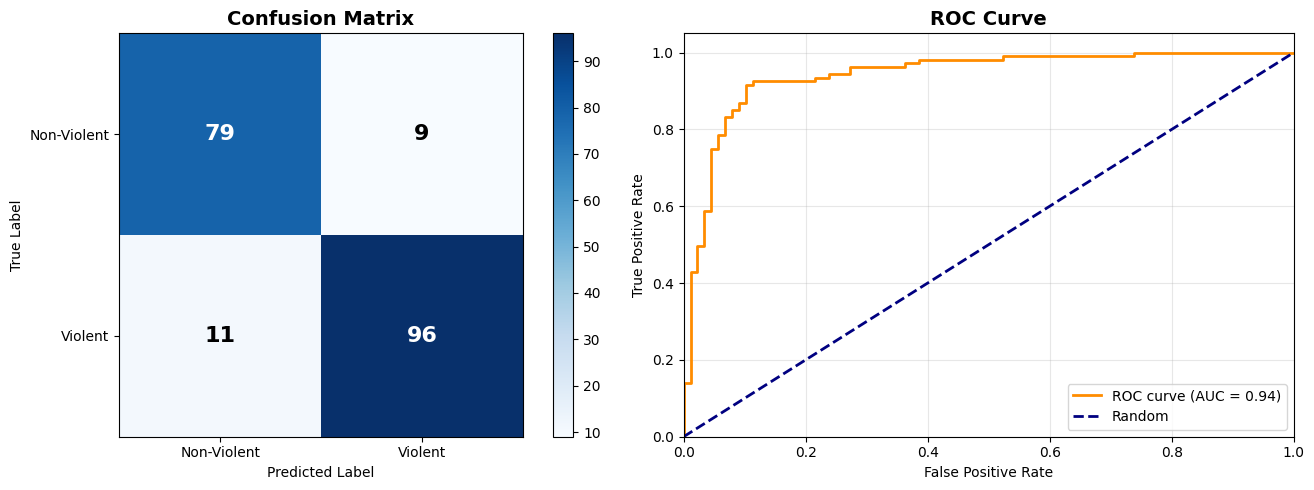

In [ ]:
# Cell 19: Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Non-Violent', 'Violent'])
axes[0].set_yticklabels(['Non-Violent', 'Violent'])

# Add values to confusion matrix
for i in range(2):
    for j in range(2):
        text = axes[0].text(j, i, cm[i, j], ha="center", va="center",
                           color="white" if cm[i, j] > cm.max()/2 else "black",
                           fontsize=16, fontweight='bold')

plt.colorbar(im, ax=axes[0])

# ROC Curve
fpr, tpr, _ = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2,
            label=f'ROC curve (AUC = {roc_auc:.2f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=14, fontweight='bold')
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

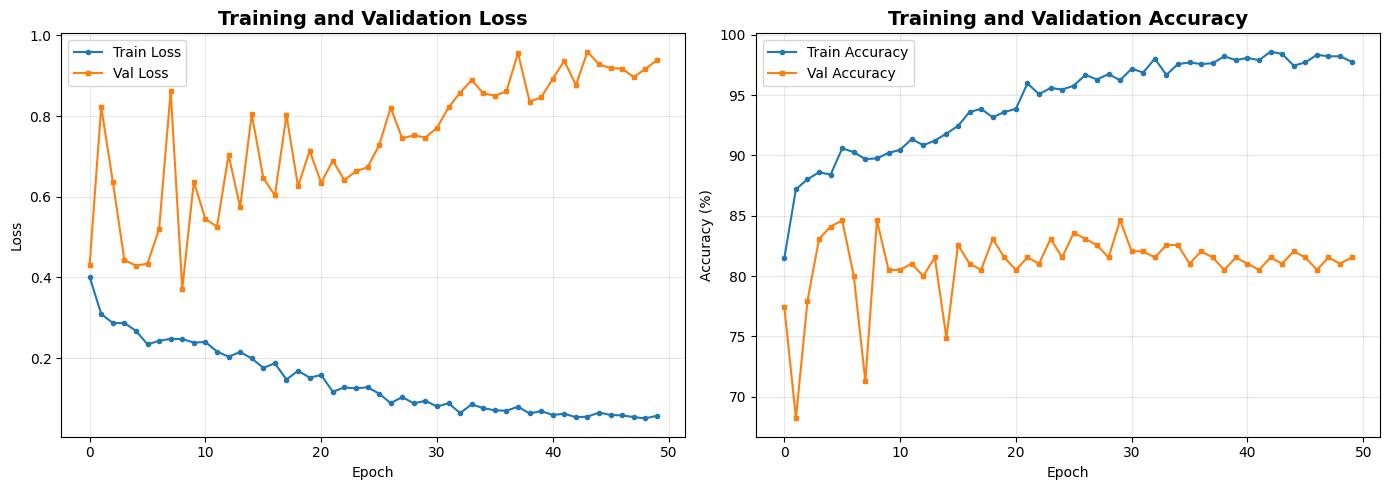

In [ ]:

# Cell 20: Training History Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(train_losses, label='Train Loss', marker='o', markersize=3)
axes[0].plot(val_losses, label='Val Loss', marker='s', markersize=3)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy plot
axes[1].plot(train_accs, label='Train Accuracy', marker='o', markersize=3)
axes[1].plot(val_accs, label='Val Accuracy', marker='s', markersize=3)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
 # Cell 21: Save Model
torch.save({
    'epoch': num_epochs,
    'model_state_dict': best_model_state,
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_acc': best_val_acc,
    'test_acc': test_acc,
}, 'stgcn_only_pipeline1.pth')

print("\n✓ Model saved successfully to 'stgcn_only_pipeline1.pth'")

# Final Summary Report
print("\n" + "="*70)
print(" "*15 + "FINAL EXPERIMENT SUMMARY - ST-GCN ONLY (PIPELINE 1)")
print("="*70)
print("\nMODEL ARCHITECTURE:")
print(f"  - ST-GCN Only (Pipeline 1 - no Attention, GAT, or KG pipelines)")
print(f"  - Total Parameters: {sum(p.numel() for p in model.parameters()):,}")

print("\nDATASET:")
print(f"  - Train samples: {len(train_dataset)}")
print(f"  - Val samples: {len(val_dataset)}")
print(f"  - Test samples: {len(test_dataset)}")

print("\nTRAINING:")
print(f"  - Epochs: {num_epochs}")
print(f"  - Best Val Accuracy: {best_val_acc:.2f}%")

print("\nTEST PERFORMANCE:")
print(f"  - Accuracy:  {test_acc*100:.2f}%")
print(f"  - Precision: {test_precision*100:.2f}%")
print(f"  - Recall:    {test_recall*100:.2f}%")
print(f"  - F1-Score:  {test_f1*100:.2f}%")
print(f"  - AUC-ROC:   {roc_auc:.2f}")

print("\n" + "="*70)
print("EXPERIMENT COMPLETED SUCCESSFULLY!")
print("="*70)
